# Earthquake Alert Classification using Machine Learning

This notebook implements an end-to-end earthquake alert classification workflow.

**Input features:** `magnitude`, `depth`, `cdi`, `mmi`, `sig`  
**Target:** `alert`

The notebook will:
1. Read the earthquake dataset.
2. Preprocess the data and save the processed dataset.
3. Train three machine-learning algorithms, one algorithm per cell.
4. Save a confusion matrix and classification report for every algorithm.
5. Compare model accuracy in a plot.
6. Save the best-performing model.
7. Generate a standalone testing script that loads the saved model and accepts keyword inputs.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

RANDOM_STATE = 42

# The notebook can be run either beside the CSV or directly in the uploaded-files environment.
if os.path.exists("earthquake_dataset.csv"):
    DATA_PATH = "earthquake_dataset.csv"
elif os.path.exists("/mnt/data/earthquake_dataset.csv"):
    DATA_PATH = "/mnt/data/earthquake_dataset.csv"
else:
    raise FileNotFoundError(
        "earthquake_dataset.csv was not found. Put the CSV in the notebook folder."
    )

OUTPUT_DIR = "earthquake_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Dataset:", DATA_PATH)
print("Output directory:", os.path.abspath(OUTPUT_DIR))


Dataset: earthquake_dataset.csv
Output directory: C:\Users\DELL\Downloads\Crisisintel_DISASTER\EARTHQAUKE_BACKEND\earthquake_outputs


## 1. Read Dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["alert"].value_counts())


Dataset shape: (1300, 6)

Columns:
['magnitude', 'depth', 'cdi', 'mmi', 'sig', 'alert']

First five rows:


,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green



Data types:
magnitude    float64
depth        float64
cdi          float64
mmi          float64
sig          float64
alert         object
dtype: object

Missing values:
magnitude    0
depth        0
cdi          0
mmi          0
sig          0
alert        0
dtype: int64

Target distribution:
alert
green     325
yellow    325
orange    325
red       325
Name: count, dtype: int64


## 2. Preprocessing and Save Processed Dataset

In [3]:
# Define features and target
FEATURES = ["magnitude", "depth", "cdi", "mmi", "sig"]
TARGET = "alert"

missing_columns = [c for c in FEATURES + [TARGET] if c not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Make a working copy
data = df[FEATURES + [TARGET]].copy()

# Convert feature columns to numeric; invalid values become NaN and are imputed below
for col in FEATURES:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Fill missing numerical values using the median
for col in FEATURES:
    data[col] = data[col].fillna(data[col].median())

# Fill missing target values with the most frequent class
if data[TARGET].isna().any():
    data[TARGET] = data[TARGET].fillna(data[TARGET].mode()[0])

# Encode target labels
label_encoder = LabelEncoder()
data["alert_encoded"] = label_encoder.fit_transform(data[TARGET].astype(str))

PROCESSED_PATH = os.path.join(OUTPUT_DIR, "processed_earthquake_dataset.csv")
data.to_csv(PROCESSED_PATH, index=False)

print("Classes:", list(label_encoder.classes_))
print("Processed dataset saved to:", PROCESSED_PATH)
display(data.head())


Classes: ['green', 'orange', 'red', 'yellow']
Processed dataset saved to: earthquake_outputs\processed_earthquake_dataset.csv


,magnitude,depth,cdi,mmi,sig,alert,alert_encoded
0,7.0,14.0,8.0,7.0,0.0,green,0
1,6.9,25.0,4.0,4.0,-33.0,green,0
2,7.0,579.0,3.0,3.0,-13.0,green,0
3,7.3,37.0,5.0,5.0,65.0,green,0
4,6.6,624.0,0.0,2.0,-98.0,green,0


## 3. Train/Test Split and Scaling

In [4]:
X = data[FEATURES]
y = data["alert_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

# A pipeline is used so preprocessing is automatically applied during training and prediction.
def make_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

class_names = list(label_encoder.classes_)
results = {}
trained_models = {}


Training samples: 1040
Testing samples : 260


## 3.1 Logistic Regression

Logistic Regression Accuracy: 0.6654

              precision    recall  f1-score   support

       green     0.9107    0.7846    0.8430        65
      orange     0.5294    0.4154    0.4655        65
         red     0.6712    0.7538    0.7101        65
      yellow     0.5750    0.7077    0.6345        65

    accuracy                         0.6654       260
   macro avg     0.6716    0.6654    0.6633       260
weighted avg     0.6716    0.6654    0.6633       260



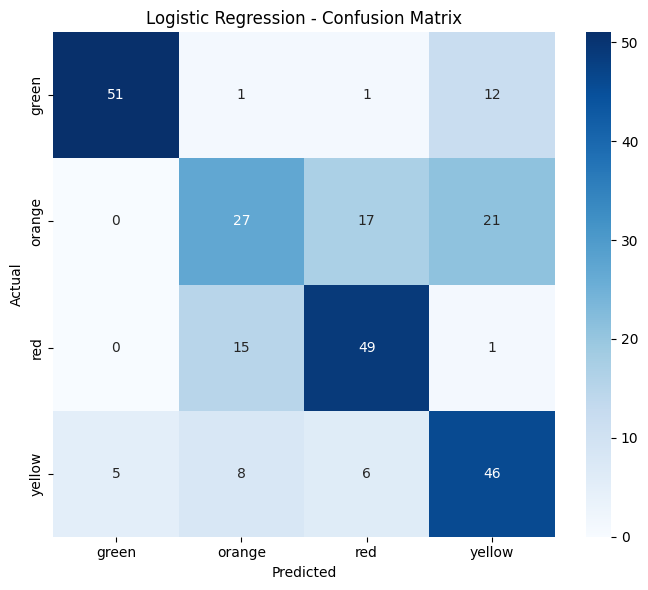

In [5]:
logistic_model = make_pipeline(
    LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    )
)

logistic_model.fit(X_train, y_train)
y_pred_lr = logistic_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_report = classification_report(
    y_test, y_pred_lr,
    target_names=class_names,
    digits=4
)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}\n")
print(lr_report)

# Save classification report
with open(os.path.join(OUTPUT_DIR, "logistic_regression_classification_report.txt"), "w") as f:
    f.write(lr_report)

# Save confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_lr, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names
)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "logistic_regression_confusion_matrix.png"), dpi=300)
plt.show()

results["Logistic Regression"] = lr_accuracy
trained_models["Logistic Regression"] = logistic_model


## 3.2 Random Forest

Random Forest Accuracy: 0.9192

              precision    recall  f1-score   support

       green     0.9655    0.8615    0.9106        65
      orange     0.9385    0.9385    0.9385        65
         red     0.9692    0.9692    0.9692        65
      yellow     0.8194    0.9077    0.8613        65

    accuracy                         0.9192       260
   macro avg     0.9232    0.9192    0.9199       260
weighted avg     0.9232    0.9192    0.9199       260



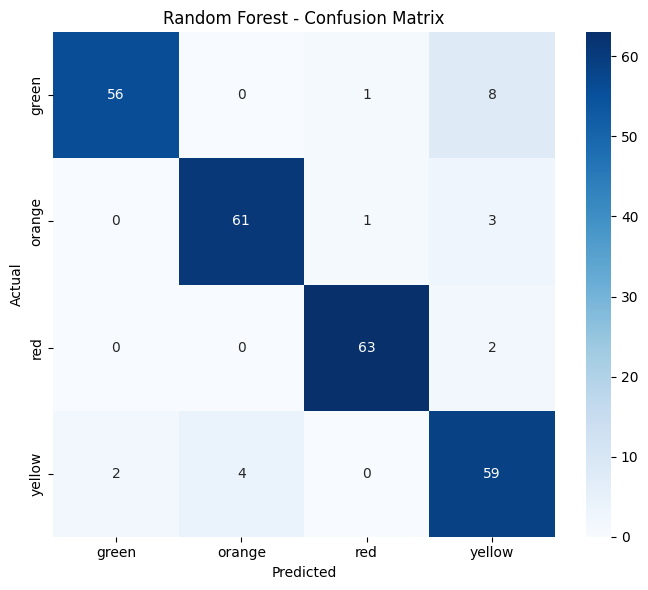

In [6]:
random_forest_model = make_pipeline(
    RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    )
)

random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_report = classification_report(
    y_test, y_pred_rf,
    target_names=class_names,
    digits=4
)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}\n")
print(rf_report)

with open(os.path.join(OUTPUT_DIR, "random_forest_classification_report.txt"), "w") as f:
    f.write(rf_report)

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_rf, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names
)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "random_forest_confusion_matrix.png"), dpi=300)
plt.show()

results["Random Forest"] = rf_accuracy
trained_models["Random Forest"] = random_forest_model


## 3.3 Support Vector Machine (SVM)

SVM Accuracy: 0.8115

              precision    recall  f1-score   support

       green     0.9808    0.7846    0.8718        65
      orange     0.7895    0.6923    0.7377        65
         red     0.7356    0.9846    0.8421        65
      yellow     0.7969    0.7846    0.7907        65

    accuracy                         0.8115       260
   macro avg     0.8257    0.8115    0.8106       260
weighted avg     0.8257    0.8115    0.8106       260



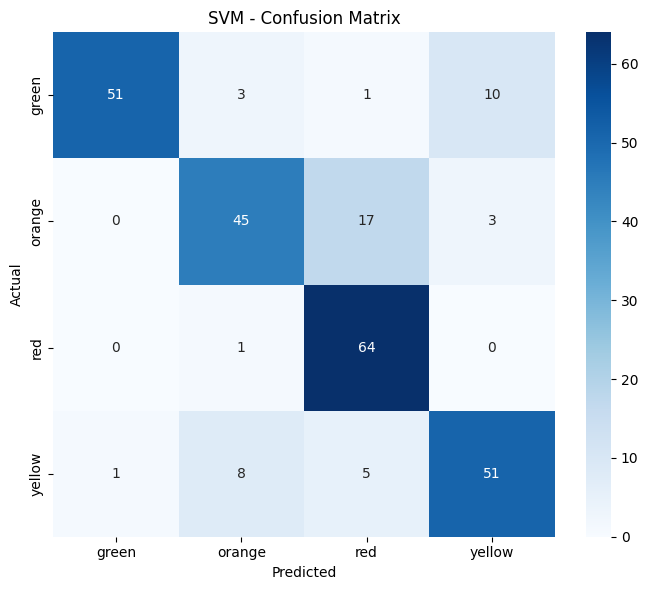

In [7]:
svm_model = make_pipeline(
    SVC(
        kernel="rbf",
        C=2.0,
        gamma="scale",
        probability=True,
        random_state=RANDOM_STATE
    )
)

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_report = classification_report(
    y_test, y_pred_svm,
    target_names=class_names,
    digits=4
)

print(f"SVM Accuracy: {svm_accuracy:.4f}\n")
print(svm_report)

with open(os.path.join(OUTPUT_DIR, "svm_classification_report.txt"), "w") as f:
    f.write(svm_report)

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_svm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names
)
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "svm_confusion_matrix.png"), dpi=300)
plt.show()

results["SVM"] = svm_accuracy
trained_models["SVM"] = svm_model


## 4. Compare Model Accuracy

,Algorithm,Accuracy
1,Random Forest,0.919231
2,SVM,0.811538
0,Logistic Regression,0.665385


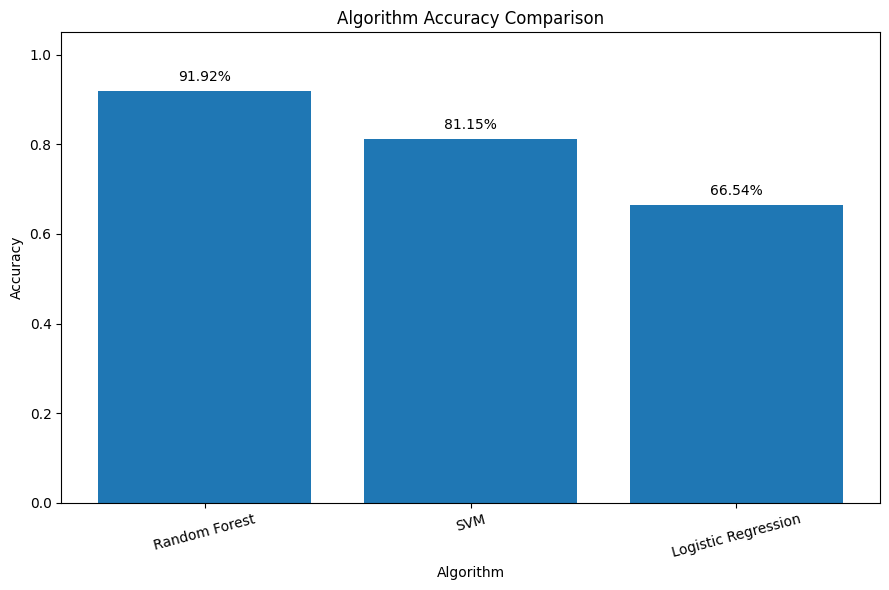

In [8]:
accuracy_df = pd.DataFrame(
    list(results.items()),
    columns=["Algorithm", "Accuracy"]
).sort_values("Accuracy", ascending=False)

display(accuracy_df)

plt.figure(figsize=(9, 6))
bars = plt.bar(accuracy_df["Algorithm"], accuracy_df["Accuracy"])
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.xlabel("Algorithm")
plt.title("Algorithm Accuracy Comparison")
plt.xticks(rotation=15)

for bar, acc in zip(bars, accuracy_df["Accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        acc + 0.015,
        f"{acc:.2%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
accuracy_plot_path = os.path.join(OUTPUT_DIR, "algorithm_accuracy_comparison.png")
plt.savefig(accuracy_plot_path, dpi=300)
plt.show()

accuracy_df.to_csv(
    os.path.join(OUTPUT_DIR, "algorithm_accuracy_comparison.csv"),
    index=False
)


## 5. Store the Best Model

In [9]:
best_algorithm = accuracy_df.iloc[0]["Algorithm"]
best_accuracy = float(accuracy_df.iloc[0]["Accuracy"])
best_model = trained_models[best_algorithm]

BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_earthquake_alert_model.joblib")
LABEL_ENCODER_PATH = os.path.join(OUTPUT_DIR, "earthquake_label_encoder.joblib")
FEATURES_PATH = os.path.join(OUTPUT_DIR, "earthquake_features.joblib")

joblib.dump(best_model, BEST_MODEL_PATH)
joblib.dump(label_encoder, LABEL_ENCODER_PATH)
joblib.dump(FEATURES, FEATURES_PATH)

print("Best algorithm:", best_algorithm)
print(f"Best accuracy : {best_accuracy:.4f} ({best_accuracy:.2%})")
print("Best model saved to:", BEST_MODEL_PATH)
print("Label encoder saved to:", LABEL_ENCODER_PATH)


Best algorithm: Random Forest
Best accuracy : 0.9192 (91.92%)
Best model saved to: earthquake_outputs\best_earthquake_alert_model.joblib
Label encoder saved to: earthquake_outputs\earthquake_label_encoder.joblib


## 6. Final Model Summary

The selected model is based **only on test-set accuracy among the three trained algorithms**. The confusion matrix and classification report files are stored in the `earthquake_outputs` directory.

> Note: The accuracy is an experimental result on this dataset/split. It should not be interpreted as a guarantee of real-world earthquake prediction performance.
